# **Pastikan sudah di download terlebih dahulu colabnya, atau di salin. Terimakasih :)**

# Supervised Learning

## Classification

### Preparation

Untuk persiapan, kita akan memanggil seluruh library yang akan kita pakai pada project kali ini

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline

In [2]:
train = pd.read_csv('messi_all_goals.csv')
# Membuat target kategorikal 'Target_Home' dari is_home_goal
train['Target_Home'] = train['is_home_goal'].astype(int)
train.head()

,competition,match_stage,date,venue,club,opponent,match_score,player_position,goal_minute,score_at_goal,goal_type,assist_player,season,goal_decade,is_home_goal,goal_minute_bucket,Target_Home
0,2ª B - Grupo III,2,2004-09-05,Home,FC Barcelona B,Girona FC,1:2,LW,65,1:2,Left-footed shot,Dani Fernández,2004-05,2000s,True,61-75,1
1,2ª B - Grupo III,4,2004-09-18,Home,FC Barcelona B,RCD Espanyol B,2:0,LW,88,2:0,Left-footed shot,Dani Fernández,2004-05,2000s,True,76-90,1
2,2ª B - Grupo III,10,2004-10-31,Away,FC Barcelona B,Villajoyosa CF,2:1,AM,2,0:1,Not reported,Not Applicable,2004-05,2000s,False,0-15,0
3,2ª B - Grupo III,14,2004-11-28,Away,FC Barcelona B,UE Figueres,2:2,AM,20,0:1,Not reported,Not Applicable,2004-05,2000s,False,16-30,0
4,2ª B - Grupo III,17,2004-12-19,Home,FC Barcelona B,CD Alcoyano,2:0,CF,40,2:0,Left-footed shot,Not Applicable,2004-05,2000s,True,31-45,1


### Exploratory Data Analysis

In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 790 entries, 0 to 789
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   competition         790 non-null    str  
 1   match_stage         790 non-null    str  
 2   date                790 non-null    str  
 3   venue               790 non-null    str  
 4   club                790 non-null    str  
 5   opponent            790 non-null    str  
 6   match_score         790 non-null    str  
 7   player_position     790 non-null    str  
 8   goal_minute         790 non-null    int64
 9   score_at_goal       790 non-null    str  
 10  goal_type           790 non-null    str  
 11  assist_player       790 non-null    str  
 12  season              790 non-null    str  
 13  goal_decade         790 non-null    str  
 14  is_home_goal        790 non-null    bool 
 15  goal_minute_bucket  790 non-null    str  
 16  Target_Home         790 non-null    int64
dtypes: bool(

In [4]:
d = train.describe()
d

,goal_minute,Target_Home
count,790.000000,790.000000
mean,51.981013,0.594937
std,26.045313,0.491215
min,2.000000,0.000000
25%,29.000000,0.000000
50%,54.000000,1.000000
75%,75.000000,1.000000
max,110.000000,1.000000


C:\Users\aldo\AppData\Local\Temp\ipykernel_7868\3761122474.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Target_Home',data=train,palette='RdBu_r')


<Axes: xlabel='Target_Home', ylabel='count'>

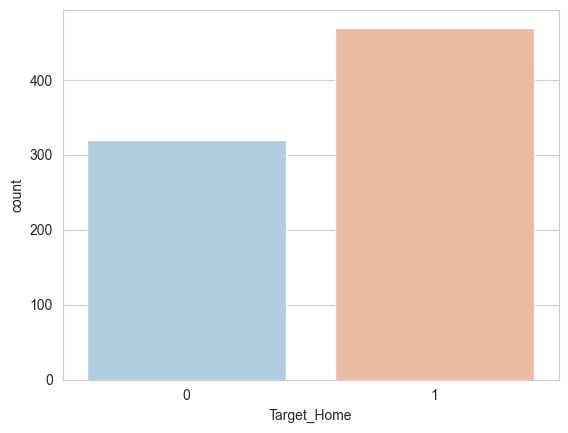

In [5]:
# Cek relative size dari kelas target
sns.set_style('whitegrid')
sns.countplot(x='Target_Home',data=train,palette='RdBu_r')

<Axes: title={'center': 'Histogram Goal Minute'}, xlabel='Goal Minute', ylabel='Count'>

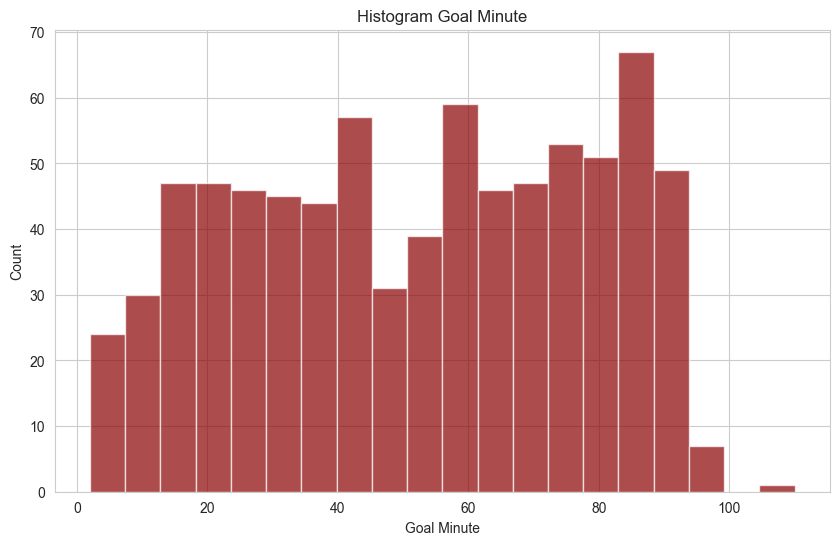

In [6]:
# Histogram Goal Minute
plt.xlabel('Goal Minute')
plt.ylabel('Count')
plt.title('Histogram Goal Minute')
train['goal_minute'].hist(bins=20, color='darkred', alpha=0.7, figsize=(10,6))

### Fitur Engineering

In [7]:
# Drop kolom yang tidak diperlukan untuk klasifikasi dan lakukan encoding
train.drop(['date', 'match_score', 'score_at_goal', 'is_home_goal', 'venue'], axis=1, inplace=True)
train = pd.get_dummies(train, drop_first=True, dtype=int)
train.head()

,goal_minute,Target_Home,competition_CONCACAF Champions Cup,competition_Club World Cup,competition_Copa del Rey,competition_LaLiga,competition_Leagues Cup,competition_Ligue 1,competition_MLS,competition_MLS Cup Playoffs,...,season_2024-25,season_2025-26,goal_decade_2010s,goal_decade_2020s,goal_minute_bucket_16-30,goal_minute_bucket_31-45,goal_minute_bucket_46-60,goal_minute_bucket_61-75,goal_minute_bucket_76-90,goal_minute_bucket_91+
0,65,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,88,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,20,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,40,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


### Training

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(train.drop('Target_Home',axis=1),
                                                    train['Target_Home'], test_size=0.30,
                                                    random_state=42)

In [9]:
print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

Train shape: (553, 315)
Test shape: (237, 315)


# **KNN**

In [10]:
from sklearn.neighbors import KNeighborsClassifier
clf1 = KNeighborsClassifier()

clf1.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [11]:
y_pred = clf1.predict(X_test)

### Evaluation

In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print('Confusion Matrix:') #confusion matrix nya
print(confusion_matrix(y_test, y_pred))

print('Classification Report:') #laporan klasifikasi
print(classification_report(y_test, y_pred))

Akurasi Model KNN: 0.57
Confusion Matrix:
[[ 34  62]
 [ 40 101]]
Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.35      0.40        96
           1       0.62      0.72      0.66       141

    accuracy                           0.57       237
   macro avg       0.54      0.54      0.53       237
weighted avg       0.55      0.57      0.56       237



# **Naive Bayes**

In [13]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

# Prediksi data uji
y_pred_nb = nb.predict(X_test)

### Evaluation

In [14]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred_nb)
print(f'Akurasi Model Naive Bayes: {accuracy:.2f}')

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_nb))

print('Classification Report:')
print(classification_report(y_test, y_pred_nb))

Akurasi Model Naive Bayes: 0.42
Confusion Matrix:
[[ 81  15]
 [122  19]]
Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.84      0.54        96
           1       0.56      0.13      0.22       141

    accuracy                           0.42       237
   macro avg       0.48      0.49      0.38       237
weighted avg       0.49      0.42      0.35       237



# **Decision Tree**

In [15]:
from sklearn.tree import DecisionTreeClassifier

# Inisialisasi dan latih model Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Prediksi data uji
y_pred_dt = dt.predict(X_test)

### Evaluation

In [16]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Evaluasi model
accuracy = accuracy_score(y_test, y_pred_dt)
print(f'Akurasi Model Decision Tree: {accuracy:.2f}')

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_dt))

print('Classification Report:')
print(classification_report(y_test, y_pred_dt))

Akurasi Model Decision Tree: 0.60
Confusion Matrix:
[[47 49]
 [46 95]]
Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.49      0.50        96
           1       0.66      0.67      0.67       141

    accuracy                           0.60       237
   macro avg       0.58      0.58      0.58       237
weighted avg       0.60      0.60      0.60       237



# **Random Forest**

In [17]:
from sklearn.ensemble import RandomForestClassifier

# Inisialisasi dan latih model Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Prediksi data uji
y_pred_rf = rf.predict(X_test)

### Evaluation

In [18]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Evaluasi model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f'Akurasi Model Random Forest: {accuracy_rf:.2f}')

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_rf))

print('Classification Report:')
print(classification_report(y_test, y_pred_rf))

Akurasi Model Random Forest: 0.61
Confusion Matrix:
[[ 31  65]
 [ 27 114]]
Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.32      0.40        96
           1       0.64      0.81      0.71       141

    accuracy                           0.61       237
   macro avg       0.59      0.57      0.56       237
weighted avg       0.60      0.61      0.59       237



Krena yang lebih bagus adalah nilai evaluasinya model Naive Bayes, maka kita akan tes menggunakan data baru

In [19]:
# Data gol baru
# Ambil satu contoh data dari test set sebagai data baru
new_data = X_test.iloc[[0]]

# Prediksi kelas
new_prediction = nb.predict(new_data)
print('Prediksi Kandang (0 = Tandang, 1 = Kandang):', new_prediction[0])

# Prediksi probabilitas
proba = nb.predict_proba(new_data)
print('Probabilitas Prediksi [Tandang, Kandang]:', proba[0])

Prediksi Kandang (0 = Tandang, 1 = Kandang): 0
Probabilitas Prediksi [Tandang, Kandang]: [1.00000000e+00 4.24472634e-65]


# **Contoh Penggunaan Parameter**

### jika kita mau mengubah parameter apa saja yang akan kita gunakan maka bisa dilakukan seperti ini

In [20]:
clf2 = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
clf2.fit(X_train, y_train)

y_pred_knn = clf2.predict(X_test)

In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred_knn) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print('Confusion Matrix:') #confusion matrix nya
print(confusion_matrix(y_test, y_pred_knn))

print('Classification Report:') #laporan klasifikasi
print(classification_report(y_test, y_pred_knn))

Akurasi Model KNN: 0.57
Confusion Matrix:
[[ 34  62]
 [ 40 101]]
Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.35      0.40        96
           1       0.62      0.72      0.66       141

    accuracy                           0.57       237
   macro avg       0.54      0.54      0.53       237
weighted avg       0.55      0.57      0.56       237



### jika ingin mencoba semua parameter kita bisa menggunakan GridSearchCV

### Contoh penggunaan Model KNN dengan GridSearchCV

In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd

# 1. Definisikan metrik-metrik scoring yang ingin digunakan
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='macro', zero_division=0),
    'recall': make_scorer(recall_score, average='macro', zero_division=0),
    'f1': make_scorer(f1_score, average='macro', zero_division=0)
}

# 2. Parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# 3. Buat model KNN
knn = KNeighborsClassifier()

# 4. GridSearch dengan semua metrik, pilih 'f1' sebagai metrik utama (refit)
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring=scoring, refit='f1', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# 5. Hasil Cross-Validation (Training)
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_metrics = cv_results[['params', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1']]
print('\n=== Hasil Evaluasi Training (Cross-Validation) ===')
print(cv_metrics.sort_values(by='mean_test_f1', ascending=False))

Fitting 5 folds for each of 12 candidates, totalling 60 fits

=== Hasil Evaluasi Training (Cross-Validation) ===
                                               params  mean_test_accuracy  \
6   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.549615   
7   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.547813   
3   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.544144   
2   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.544144   
5   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.536937   
4   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.536937   
11  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            0.533219   
10  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            0.533251   
0   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.513382   
1   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.513382   
8   {'metric': 'manhattan', 'n_neighbors

In [23]:
# Simpan hasil evaluasi ke file Excel
cv_metrics_sorted = cv_metrics.sort_values(by='mean_test_f1', ascending=False)
cv_metrics_sorted.to_excel('hasil_gridsearch_knn.xlsx', index=False)

print("Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'")


Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'


In [24]:
best_model = grid_search.best_estimator_
print('\n=== Parameter Terbaik ===')
print(grid_search.best_params_)


=== Parameter Terbaik ===
{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}


In [25]:
y_pred = best_model.predict(X_test)
print('\n=== Evaluasi di Test Set ===')
print(f'Akurasi:  {accuracy_score(y_test, y_pred):.2f}')
print(f'Presisi:  {precision_score(y_test, y_pred, average="macro", zero_division=0):.2f}')
print(f'Recall:   {recall_score(y_test, y_pred, average="macro", zero_division=0):.2f}')
print(f'F1-Score: {f1_score(y_test, y_pred, average="macro", zero_division=0):.2f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, zero_division=0))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))


=== Evaluasi di Test Set ===
Akurasi:  0.51
Presisi:  0.48
Recall:   0.48
F1-Score: 0.48

Classification Report:
              precision    recall  f1-score   support

           0       0.38      0.33      0.36        96
           1       0.58      0.63      0.61       141

    accuracy                           0.51       237
   macro avg       0.48      0.48      0.48       237
weighted avg       0.50      0.51      0.50       237

Confusion Matrix:
[[32 64]
 [52 89]]


In [26]:
import numpy as np

# Data gol baru (dalam urutan sama seperti fitur model)
new_data_1 = X_test.iloc[[0]]

# Prediksi apakah gol ini dicetak di kandang atau tandang
prediction = best_model.predict(new_data_1)

print('Prediksi (0 = Tandang, 1 = Kandang):', prediction[0])

Prediksi (0 = Tandang, 1 = Kandang): 0
